# Data exploration — data.db

Tweets/replies collected for the accounts in `src/config.py::TARGETS`.

In [94]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 80)

conn = sqlite3.connect("../data.db")

import sys, os
sys.path.insert(0, os.path.abspath(".."))
from src.config import TARGETS

tweets = pd.read_sql_query("SELECT * FROM tweets", conn, parse_dates=["created_at"])
users = pd.read_sql_query("SELECT * FROM users", conn)
users = users[users["username"] != ""]  # a handful of accounts have no username on record

tweets = tweets.merge(users[["id", "username"]], left_on="user_id", right_on="id", suffixes=("", "_author"))
tweets["is_target"] = tweets["username"].isin(TARGETS)
tweets["is_reply"] = tweets["parent_tweet_id"].notna()

print(f"{len(tweets):,} tweets from {tweets['user_id'].nunique():,} unique users")
print(f"{len(users):,} user profiles cached")

451,515 tweets from 140,107 unique users
140,107 user profiles cached


## 1. Coverage — profile `tweets_count` vs tweets actually collected (see `tools/coverage.py`)

In [95]:
coverage = tweets.groupby("user_id").agg(own=("is_reply", lambda s: (~s).sum()), total=("is_reply", "size"))
coverage = users.set_index("id")[["username", "tweets_count"]].join(coverage)
coverage = coverage.set_index("username").reindex(TARGETS)
coverage[["tweets_count", "own", "total"]] = coverage[["tweets_count", "own", "total"]].fillna(0).astype(int)
coverage["pct"] = coverage["own"] / coverage["tweets_count"].replace(0, pd.NA) * 100
coverage.sort_values("pct", ascending=False)

,tweets_count,own,total,pct
username,,,,
USIPorg,52,52,52,100.000000
AIPACofficial,2,2,2,100.000000
osekguub6096Gwf,15,14,15,93.333333
Pontifex_ar,728,639,682,87.774725
fm6oaorg,2396,1826,1826,76.210351
MmedHamdaoui,1104,841,887,76.177536
SecRubio,1296,812,821,62.654321
nosraorg,1233,769,786,62.368208
alimamaltayeb,662,399,564,60.271903


## 2. How many tweets did we extract per target

In [96]:
root_tweets = tweets[~tweets["is_reply"]]
per_target = root_tweets[root_tweets["is_target"]].groupby("username").size().reindex(TARGETS).fillna(0).astype(int)
per_target = per_target.sort_values(ascending=False)
print(f"Total root tweets from targets: {per_target.sum():,} / {len(TARGETS)} targets ({(per_target > 0).sum()} with data)")
per_target.to_frame("tweets")

Total root tweets from targets: 28,487 / 39 targets (39 with data)


,tweets
username,
fm6oaorg,1826
habousmaroc,849
MmedHamdaoui,841
CUFI,841
RTErdogan,840
GovMikeHuckabee,837
mfa_russia,832
IRIMFA_EN,832
TheIRD,826


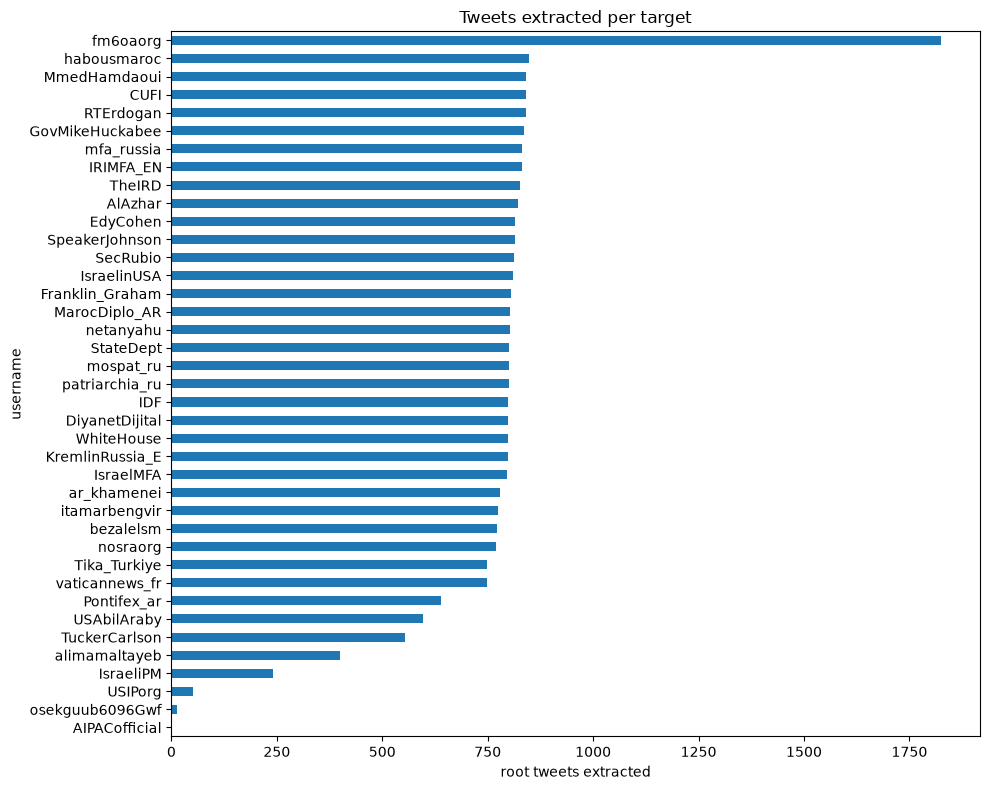

In [97]:
fig, ax = plt.subplots(figsize=(10, 8))
per_target.plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_xlabel("root tweets extracted")
ax.set_title("Tweets extracted per target")
plt.tight_layout()

## 3. Most liked tweets

In [98]:
tweets.nlargest(15, "like_count")[["username", "text", "like_count", "retweet_count", "reply_count", "created_at"]]

,username,text,like_count,retweet_count,reply_count,created_at
34902,realDonaldTrump,https://t.co/MlIKklPSJT https://t.co/Mcbf2xozsY,1786663,362091,311704,2023-08-25 01:38:08+00:00
6078,realDonaldTrump,Happy 20th Anniversary to Melania! https://t.co/VIcXSQb4QO,1323906,82362,58302,2025-01-22 20:01:23+00:00
26841,realDonaldTrump,https://t.co/YkLtEaC3OI,1323402,111117,30723,2024-10-21 04:09:31+00:00
1744,realDonaldTrump,TO MY GREAT FELLOW AMERICANS… https://t.co/oRsrE5TTHr,1278149,182681,63806,2025-09-11 01:15:39+00:00
2281,realDonaldTrump,https://t.co/wu9mMkxtUg,1229006,133252,172959,2025-06-21 23:53:21+00:00
2211,realDonaldTrump,https://t.co/2uweRciDEo,1191611,109931,153795,2025-06-22 02:30:31+00:00
8729,realDonaldTrump,HI REPUBLICANS! IF YOU’RE IN LINE—STAY IN LINE… https://t.co/5vEA2kXZXU,1020377,94805,31012,2024-11-06 00:33:07+00:00
6557,realDonaldTrump,https://t.co/dt3qNahL3Q,996018,99219,33014,2024-12-25 22:46:14+00:00
664,realDonaldTrump,https://t.co/BZuJDudLej,994520,152992,150973,2026-02-28 07:44:23+00:00
3049,realDonaldTrump,https://t.co/lRPhZpugBV,976953,115722,120425,2025-05-10 12:03:09+00:00


## 4. Most commented (replied-to) tweets

In [99]:
tweets.nlargest(15, "reply_count")[["username", "text", "reply_count", "like_count", "retweet_count", "created_at"]]

,username,text,reply_count,like_count,retweet_count,created_at
35050,realDonaldTrump,I am asking for everyone at the U.S. Capitol to remain peaceful. No violence...,311784,769808,178413,2021-01-06 20:13:26+00:00
34902,realDonaldTrump,https://t.co/MlIKklPSJT https://t.co/Mcbf2xozsY,311704,1786663,362091,2023-08-25 01:38:08+00:00
34939,realDonaldTrump,"To all of those who have asked, I will not be going to the Inauguration on J...",300161,691647,81917,2021-01-08 15:44:28+00:00
34532,realDonaldTrump,https://t.co/PLHekD9jzW,293453,665359,123827,2024-08-12 23:47:31+00:00
35013,realDonaldTrump,https://t.co/csX07ZVWGe,192520,680359,133779,2021-01-08 00:10:24+00:00
2281,realDonaldTrump,https://t.co/wu9mMkxtUg,172959,1229006,133252,2025-06-21 23:53:21+00:00
627,realDonaldTrump,https://t.co/uAxTGrJisv,162526,605169,77496,2026-03-02 16:20:05+00:00
2211,realDonaldTrump,https://t.co/2uweRciDEo,153795,1191611,109931,2025-06-22 02:30:31+00:00
35087,realDonaldTrump,Please support our Capitol Police and Law Enforcement. They are truly on the...,151024,553754,97015,2021-01-06 19:38:58+00:00
664,realDonaldTrump,https://t.co/BZuJDudLej,150973,994520,152992,2026-02-28 07:44:23+00:00


## 5. Accounts that engage most (reply volume, not targets themselves)

In [100]:
repliers = tweets[tweets["is_reply"] & ~tweets["is_target"]]
top_repliers = repliers.groupby("username").size().nlargest(20)
top_repliers.to_frame("replies_sent")

,replies_sent
username,
TamaraAlexis,998
TRUMP_ARMY_,903
Skitzamizrahit,826
GuntherEagleman,742
Bubblebathgirl,677
1AlasadiHayder,656
Galipilhaner,627
Dede_Watson,623
zadokq244514,560


## 6. Which targets attract the most replies (most engaging targets)

In [101]:
parent_author = tweets.set_index("id")["username"]
replies_only = tweets[tweets["is_reply"]].copy()
replies_only["parent_author"] = replies_only["parent_tweet_id"].map(parent_author)
replies_only.groupby("parent_author").size().sort_values(ascending=False).to_frame("replies_received")

,replies_received
parent_author,
RTErdogan,28753
IDF,27581
netanyahu,26849
SpeakerJohnson,25769
bezalelsm,24937
GovMikeHuckabee,23390
realDonaldTrump,22703
EdyCohen,21435
itamarbengvir,21316


## 7. Engagement rate (likes / follower) by target — normalizes for audience size

In [102]:
followers = users.set_index("username")["followers"]
eng = root_tweets[root_tweets["is_target"]].groupby("username").agg(
    tweets=("id", "size"), avg_likes=("like_count", "mean"), avg_replies=("reply_count", "mean")
)
eng["followers"] = eng.index.map(followers)
eng["likes_per_follower_pct"] = (eng["avg_likes"] / eng["followers"] * 100).round(3)
eng.sort_values("likes_per_follower_pct", ascending=False)

,tweets,avg_likes,avg_replies,followers,likes_per_follower_pct
username,,,,,
AIPACofficial,2,2.500000,2.000000,42,5.952
osekguub6096Gwf,14,1.785714,0.071429,81,2.205
nosraorg,769,150.634590,3.048114,7194,2.094
MmedHamdaoui,841,60.510107,3.010702,5560,1.088
SecRubio,812,16981.990148,1651.785714,2064900,0.822
SpeakerJohnson,814,7149.606880,1575.757985,1220649,0.586
USIPorg,52,1.307692,0.115385,251,0.521
alimamaltayeb,399,3241.827068,145.934837,793107,0.409
ar_khamenei,778,3549.619537,308.491003,888925,0.399


## 8. Tweet volume over time (by month)

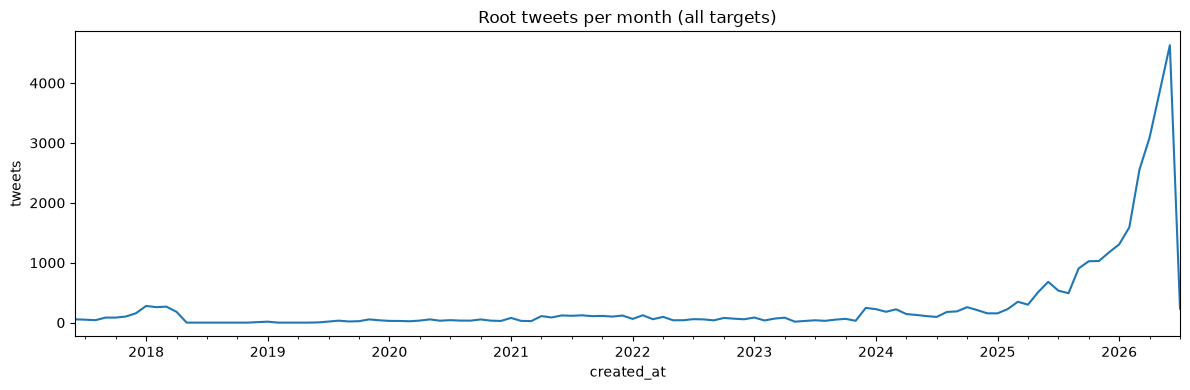

In [103]:
monthly = root_tweets.set_index("created_at").resample("MS").size()
fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(ax=ax)
ax.set_title("Root tweets per month (all targets)")
ax.set_ylabel("tweets")
plt.tight_layout()

## 9. Posting cadence — hour of day / day of week heatmap

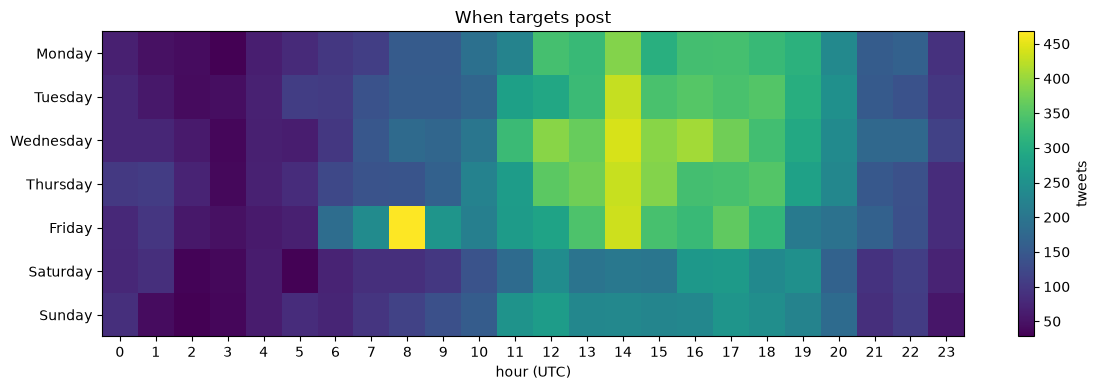

In [104]:
hod = root_tweets["created_at"].dt.hour
dow = root_tweets["created_at"].dt.day_name()
pivot = pd.crosstab(dow, hod).reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot, aspect="auto", cmap="viridis")
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_xticks(range(24)); ax.set_xticklabels(range(24))
ax.set_xlabel("hour (UTC)")
fig.colorbar(im, label="tweets")
ax.set_title("When targets post")
plt.tight_layout()

## 10. Reply-to-like ratio — most controversial / debated tweets

In [105]:
controversial = tweets[tweets["like_count"] >= 20].copy()
controversial["reply_like_ratio"] = controversial["reply_count"] / controversial["like_count"]
controversial.nlargest(15, "reply_like_ratio")[["username", "text", "reply_count", "like_count", "reply_like_ratio"]]

,username,text,reply_count,like_count,reply_like_ratio
6228,Mavericks100xs,@realDonaldTrump If you missed $TRUMP\n\nDont miss $wTRUMP its officially pa...,2331,197,11.832487
96104,CailinElissa,@WhiteHouse Are you fucking five years old? Randomly capitalizing words that...,198,23,8.608696
327356,IsraelinUSA,"In the last 72 hours, the Iranian regime has shown the world exactly what it...",550,70,7.857143
4622,Crazymoments01,@realDonaldTrump Describe President Trump's in one word? https://t.co/KredSP...,388,58,6.689655
4413,Crazymoments01,@realDonaldTrump Describe President Trump in one word? https://t.co/6maMmzq0w7,185,29,6.379310
203341,RTErdogan,Mayıs ayının son haftası münasebetiyle idrak edilen #MilliAileHaftası’nın ül...,54720,8884,6.159388
226827,mfa_russia,"⚔️ April 25, 1945 – the #ElbeDay – a memorable date in Russia’s military his...",1582,278,5.690647
327856,IsraelinUSA,"""They are using cluster bombs at centers of heavily populated areas, in orde...",385,70,5.500000
105158,Gamma_Monkey,@WhiteHouse President Trump is showing the world what REAL leadership looks ...,130,24,5.416667
67591,NobodymrRobert,@TuckerCarlson What would you throw him https://t.co/hm5J9hkxWw,119,22,5.409091


## 11. Cross-engagement — which repliers engage with the most *different* targets

In [106]:
cross = replies_only[replies_only["parent_author"].isin(TARGETS)]
cross_engagers = cross.groupby("username")["parent_author"].nunique().sort_values(ascending=False)
cross_engagers.head(20).to_frame("distinct_targets_replied_to")

,distinct_targets_replied_to
username,
redbrasco,15
Disciple4Lif,15
BabylonBiBi,14
koshercockney,13
DavidProwess_,13
NABEELRAJAB,13
ilbannay,12
MacroBombastic,12
YouthAlertYA,12


## 12. Follower distribution of the target accounts

In [107]:
users[users["username"].isin(TARGETS)].set_index("username")["followers"].sort_values(ascending=False).to_frame()

,followers
username,
RTErdogan,19665966
TuckerCarlson,17772642
StateDept,6750817
WhiteHouse,4959437
netanyahu,4183134
IDF,3307515
Franklin_Graham,2884672
SecRubio,2064900
KremlinRussia_E,2035631


## 13. Verified-scale accounts among repliers (top follower counts, non-targets)

In [108]:
replier_ids = repliers["user_id"].unique()
big_repliers = users[users["id"].isin(replier_ids) & ~users["username"].isin(TARGETS)]
big_repliers.nlargest(15, "followers")[["username", "followers", "tweets_count", "bio"]]

,username,followers,tweets_count,bio
29755,elonmusk,240649333,0,Starmind
6877,realDonaldTrump,111701496,59834,45th & 47th President of the United States of America🇺🇸
15463,DonaldJTrumpJr,16229775,0,Co-Founder @worldlibertyfi
632,cz_binance,11661019,0,Buy the book (proceeds go to charity):\nEnglish: https://t.co/UxgYxYJ3NF\nCh...
22341,Cobratate,10899048,0,Unmatched perspicacity coupled with sheer indefatigability makes me a feared...
66,AlarabyTV,9665631,0,التلفزيون العربي.. الصورة الأوضح تابعوا تغطيتنا للأخبار العاجلة على مدار الس...
6167,adwock,9001529,0,"Everything you need to stay ahead. ai, business, startups, robotics, investm..."
15460,piersmorgan,8881448,0,https://t.co/SPMyQj5XVr
99365,grok,8836909,0,@grok it
83156,RealCandaceO,7821852,0,https://t.co/RjlP6s2QoD


## 14. Average engagement per target (likes + retweets + replies) — reach proxy

In [109]:
eng2 = root_tweets[root_tweets["is_target"]].assign(
    engagement=lambda d: d["like_count"] + d["retweet_count"] + d["reply_count"]
).groupby("username")["engagement"].mean().sort_values(ascending=False)
eng2.to_frame("avg_engagement_per_tweet")

,avg_engagement_per_tweet
username,
TuckerCarlson,53124.234657
SecRubio,23161.641626
netanyahu,17579.648379
RTErdogan,14854.997619
WhiteHouse,11385.849624
SpeakerJohnson,10680.251843
StateDept,5762.254682
IDF,5573.394243
ar_khamenei,4407.453728


## 15. View-to-engagement conversion (like / view ratio) — content quality signal

In [110]:
viewed = tweets[tweets["view_count"] > 0].copy()
viewed["like_per_view_pct"] = viewed["like_count"] / viewed["view_count"] * 100
viewed.groupby("username")["like_per_view_pct"].mean().sort_values(ascending=False).head(20).to_frame()

,like_per_view_pct
username,
AliMolavi54092,100.0
BnmbnMhamd60137,100.0
MT7976503382088,100.0
Mo5821233835911,100.0
Christiano70147,100.0
SaadAghail,100.0
SkioD2441,100.0
MichaelHar78621,100.0
ammar_algarady,100.0


## 16. Text length vs engagement — does tweet length correlate with likes?

In [111]:
root_tweets["text_len"] = root_tweets["text"].str.len()
bins = pd.cut(root_tweets["text_len"], bins=[0, 50, 100, 150, 200, 280, 10000])
root_tweets.groupby(bins, observed=True)["like_count"].mean().to_frame("avg_likes")

,avg_likes
text_len,
"(0, 50]",45605.053047
"(50, 100]",10702.516628
"(100, 150]",1875.975376
"(150, 200]",4768.407517
"(200, 280]",6196.052319
"(280, 10000]",7410.127992


## 17. Reply chain depth — how deep do conversations go under target tweets

count    18095.000000
mean        23.206687
std         15.116385
min          1.000000
25%          5.000000
50%         35.000000
75%         36.000000
max         66.000000
dtype: float64

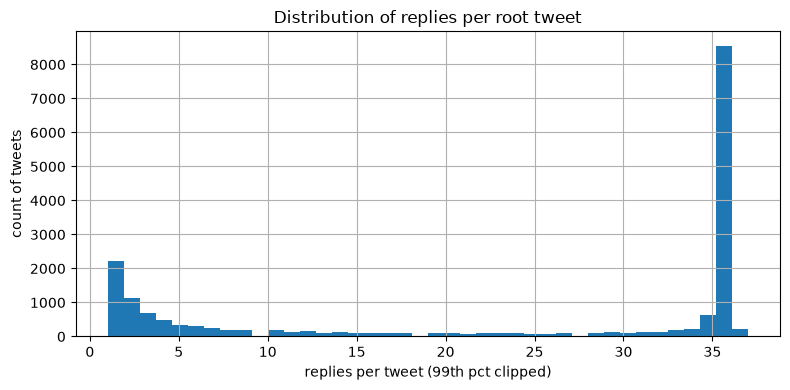

In [112]:
reply_depth = replies_only.groupby("parent_tweet_id").size()
fig, ax = plt.subplots(figsize=(8, 4))
reply_depth.clip(upper=reply_depth.quantile(0.99)).hist(bins=40, ax=ax)
ax.set_xlabel("replies per tweet (99th pct clipped)")
ax.set_ylabel("count of tweets")
ax.set_title("Distribution of replies per root tweet")
plt.tight_layout()
reply_depth.describe()